<a href="https://colab.research.google.com/github/rtajeong/M3_2026/blob/main/lab54_word_vector_rev3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Word Embedding
- express words using vectors
- vectors are trained

# Word2Vec - 한국어

- 지금까지의 텍스트 코딩 방식인 One-hot encoding, BoW(단어모음)-문서-단어 행렬 방식은 모두 단어마다 고유번호를 배정하여 사용하지만, 이 번호들에는 아무런 의미가 포함되어 있지 않고 단지 인덱스 역할만 함.
- Word Vector 에서는
 - 단어를 고차원 공간상의 벡터로 표현함으로 단어간 거리 표현 가능. 차원이 높을수록 정교한 의미 구분 가능.
 - 보통 50~300 개 정도의 차원을 사용함
 - 단어간의 거리 (유사도) 뿐 아니라 방향성(벡터)도 찾을 수 있음.
 - 단어벡터의 각 성분이 어떤 의미를 갖는지는 알 수 없다.

- 빅카인즈 뉴스기사 데이터 활용(https://www.bigkinds.or.kr/)

## 뉴스를 이용한 단어 벡터 생성
- 단어 추출: konlpy 의 kkma() 사용
- 단어 벡터 생성: gensim 의 word2vec() 사용

In [1]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 44.3 MB/s eta 0:00:00


In [2]:
!pip install konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 16.9 MB/s eta 0:00:00


In [3]:
from konlpy.tag import Kkma     # 형태소 분석 및 자연어 처리 모듈 (서울대)
from gensim.models.word2vec import Word2Vec

In [5]:
# IT 뉴스기사를 이용한다
# !wget https://bit.ly/2X7UON2 -O news2018.xlsx
!curl -L "https://github.com/swkim01/DSAC3/raw/main/news.xlsx" -o news2018.xlsx

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 1789k  100 1789k    0     0  4569k      0 --:--:-- --:--:-- --:--:-- 11.4M


In [6]:
import pandas as pd
news = pd.read_excel("news2018.xlsx")

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [7]:
news.head(2)

,뉴스 식별자,일자,언론사,기고자,제목,통합 분류1,통합 분류2,통합 분류3,사건/사고 분류1,사건/사고 분류2,사건/사고 분류3,인물,위치,기관,키워드,특성추출,본문,URL,분석제외 여부
0,1.500401e+06,20190228,국제신문,김태경 기자 tgkim@kookje.co.kr,빅딜이냐 스몰딜이냐 ‘영변 핵+α’ 로드맵 도출이 관건,정치>북한,정치>외교,NaN,NaN,NaN,NaN,"김,도널드 트럼프,김의겸,김정은","북미,미국,하노이,서울,싱가포르,북한,리비아","북미,북미 정상회,미국,청와대,북미 정상회담,북한,국무위","빅딜,스몰딜,영변,로드맵,도출,비핵화,수준,상응,조치,막판,양국,협상팀,밀당,1차,...","북미,비핵화,미국,스몰딜,1차,정상회담,김정은,종전선언,연락사무소,하노이,영변,대변...",- 비핵화 수준 상응 조치 놓고\n- 양국 협상팀 막판까지 ‘밀당’\n- 1차 때와...,http://www.kookje.co.kr/news2011/asp/newsbody....,NaN
1,1.200201e+06,20190228,경인일보,조영상,"하노이 도착후 실무대표단 청취 김정은, 북미회담 성공 '잰걸음'",국제>국제일반,정치>북한,NaN,NaN,NaN,NaN,김,"북미,하노이,베트남","조선중앙통신,국무위","하노이,도착,실무대표단,청취,김정은,잰걸음,북미회담,성공,김정은,국무,위원장,시작,...","실무대표단,하노이,김정은,위원장,베트남,북미정상회담,북미회담,정상회담,조선중앙통신,...",김정은 국무위원장이 27일 시작되는 제2차 북미정상회담 성공을 위해 심혈을 기울이고...,http://www.kyeongin.com/main/view.php?key=2019...,NaN


In [8]:
news["본문"][:4]

,본문
0,- 비핵화 수준 상응 조치 놓고\n- 양국 협상팀 막판까지 ‘밀당’\n- 1차 때와...
1,김정은 국무위원장이 27일 시작되는 제2차 북미정상회담 성공을 위해 심혈을 기울이고...
2,북미가 처음으로 정상 간 단독회담과 만찬을 가지며 또다시 새로운 역사 창조에 나섰다...
3,지난해 9월 남북정상회담 당시 리선권 북한 조국평화통일위원장의 '냉면' 발언으로 정...


In [9]:
kkma = Kkma()

sentence_list = []
for sent in news["본문"]:

    sent_kkma_pos = kkma.nouns(sent)   # 명사만 추출
    word_list = []
    for word_pos in sent_kkma_pos:
        word_list.append(word_pos)

    sentence_list.append(word_list)

In [10]:
print(sentence_list[0])

['비핵화', '수준', '상응', '조치', '양국', '협상', '협상팀', '팀', '막판', '당', '1', '1차', '차', '때', '시간', '조율', '단계적', '접근', '동의', '예상', '종전', '종전선언', '선언', '연락', '연락사무소', '사무소', '개설', '등', '조건', '조건부', '부', '제재', '완화', '명시', '가능성', '북미', '북미회담', '회담', '빅딜', '성공', '김', '김정은', '정은', '답방', '결과', '연관', '북한', '국무', '국무위원장', '위원장', '도', '도널드', '널드', '트럼프', '미국', '대통령', '27', '27일', '일', '친교', '만찬']


In [11]:
for i in range(3):
    print(sentence_list[i])

['비핵화', '수준', '상응', '조치', '양국', '협상', '협상팀', '팀', '막판', '당', '1', '1차', '차', '때', '시간', '조율', '단계적', '접근', '동의', '예상', '종전', '종전선언', '선언', '연락', '연락사무소', '사무소', '개설', '등', '조건', '조건부', '부', '제재', '완화', '명시', '가능성', '북미', '북미회담', '회담', '빅딜', '성공', '김', '김정은', '정은', '답방', '결과', '연관', '북한', '국무', '국무위원장', '위원장', '도', '도널드', '널드', '트럼프', '미국', '대통령', '27', '27일', '일', '친교', '만찬']
['김', '김정은', '정은', '국무', '국무위원장', '위원장', '27', '27일', '일', '시작', '저', '2', '2차', '차', '북미', '북미정상회담', '정상', '회담', '성공', '심혈', '조선', '조선중앙통신', '중앙', '통신', '이날', '26', '26일', '하노이', '도착', '리', '호텔', '실무', '실무대표단', '대표단', '보고', '조미', '수뇌', '수뇌회담', '성공적', '보장', '나라', '현지', '파견', '사이', '접촉', '정형', '결과', '을', '구체적', '청취']
['북미', '처음', '정상', '간', '단독', '단독회담', '회담', '만찬', '역사', '창조', '결', '물', '도출', '북측', '영', '영변', '변', '핵', '핵시설', '시설', '폐기', '외', '추가', '추가적인', '적인', '비핵화', '조치', '미국', '금강산', '금강산관광', '관광', '등', '경제적', '체제', '체제보장', '보장', '여부', '양', '간', '톱', '담판', '김', '북한', '국무', '국무위원장', '위원장', '도', '도널드', '널드', '트럼

In [12]:
news.shape, len(sentence_list)

((1543, 19), 1543)

In [13]:
[len(w) for w in sentence_list][:10]

[61, 50, 63, 48, 44, 38, 38, 60, 52, 39]

In [14]:
model = Word2Vec(sentence_list, sg=1, vector_size=100)   #sg=1 (skip-gram), 0(CBOW)

In [15]:
model.wv["대한민국"]

array([-0.01869312,  0.10401522,  0.00207688,  0.06551497, -0.04436478,
       -0.15761997,  0.04485488,  0.24629606, -0.12578931,  0.03683792,
        0.00435436, -0.1911859 , -0.02635654,  0.0843896 , -0.04042739,
       -0.07158389,  0.09145349, -0.25660405, -0.05583882, -0.15906566,
       -0.0827058 ,  0.0884168 ,  0.05614363, -0.0819047 , -0.11653018,
       -0.09566964, -0.19390734, -0.05112061, -0.17996413,  0.02045562,
        0.02675217,  0.06799682,  0.11934023, -0.10109606, -0.03914583,
        0.2223752 ,  0.01577976, -0.18397206,  0.00565922, -0.36296052,
       -0.10229473, -0.1779527 ,  0.06938948, -0.11354005,  0.02201022,
        0.02794383, -0.07092629, -0.08002473,  0.064779  ,  0.13062535,
        0.07998397, -0.06089305, -0.00424853, -0.0540395 , -0.07838428,
       -0.03801835,  0.16603243,  0.06200214, -0.19130296,  0.12194424,
       -0.02687941,  0.06154103, -0.17301713, -0.01206808, -0.139869  ,
        0.10248793,  0.201483  ,  0.04285496, -0.0749234 ,  0.25

In [16]:
for index, word in enumerate(model.wv.index_to_key):
    if index == 10:
        break
    print("word {}/{} is {}".format(index, len(model.wv.index_to_key),word ))

word 0/1956 is 회담
word 1/1956 is 일
word 2/1956 is 북미
word 3/1956 is 차
word 4/1956 is 2
word 5/1956 is 정상
word 6/1956 is 2차
word 7/1956 is 김
word 8/1956 is 북한
word 9/1956 is 미국


In [17]:
print(model.wv.most_similar("대한민국"))

[('박근혜', 0.9930165410041809), ('민국', 0.992568850517273), ('대한', 0.9924802184104919), ('박근', 0.9918574094772339), ('마감', 0.9915252327919006), ('증권', 0.9899241328239441), ('현대', 0.9897878170013428), ('경남', 0.989493727684021), ('선수', 0.9889325499534607), ('전체', 0.9884849786758423)]


In [18]:
print(model.wv.similarity("한국","미국"))
print(model.wv.similarity("한국","일본"))
print(model.wv.similarity("미국","일본"))

0.23697408
0.44799647
0.6406087


In [19]:
# storing and loading the model
model.save('tmp_word2vec.model')
model = Word2Vec.load("tmp_word2vec.model")

In [20]:
# a:b = c: ?
model.wv.most_similar(positive=['한국', '미국'], negative=['서울'])

[('도널드', 0.6330668926239014),
 ('행정부', 0.6084079146385193),
 ('미', 0.599877119064331),
 ('널드', 0.5822199583053589),
 ('기간', 0.5815759897232056),
 ('아베', 0.5744621753692627),
 ('핵', 0.573096513748169),
 ('주요', 0.5713005661964417),
 ('성명', 0.5701116323471069),
 ('18', 0.5699367523193359)]

## Keras 에서 word2vec 훈련된 모델 사용하기 (그림형제 동화 예제)

In [21]:
import requests
import re
res = requests.get('https://www.gutenberg.org/files/2591/2591-0.txt')
grimm = res.text[2801:530661]                 # 그림형제의 동화 일부만 사용
grimm = re.sub(r'[^a-zA-Z\. ]', ' ', grimm)   # not starting with [alphabets, ., space] -> ' ' in grimm
sentences = grimm.split('. ')                 # 문장 단위로 자름
data = [s.lower().split() for s in sentences]

In [22]:
res.text[:100], len(res.text)

('\ufeffThe Project Gutenberg eBook of Grimms’ Fairy Tales, by Jacob Grimm and Wilhelm Grimm\r\n\r\nThis eBook ',
 549750)

In [23]:
len(data)  # number of sentences

3530

In [24]:
print(data[:2])

[['the', 'salad', 'the', 'story', 'of', 'the', 'youth', 'who', 'went', 'forth', 'to', 'learn', 'what', 'fear', 'was', 'king', 'grisly', 'beard', 'iron', 'hans', 'cat', 'skin', 'snow', 'white', 'and', 'rose', 'red', 'the', 'brothers', 'grimm', 'fairy', 'tales', 'the', 'golden', 'bird', 'a', 'certain', 'king', 'had', 'a', 'beautiful', 'garden', 'and', 'in', 'the', 'garden', 'stood', 'a', 'tree', 'which', 'bore', 'golden', 'apples'], ['these', 'apples', 'were', 'always', 'counted', 'and', 'about', 'the', 'time', 'when', 'they', 'began', 'to', 'grow', 'ripe', 'it', 'was', 'found', 'that', 'every', 'night', 'one', 'of', 'them', 'was', 'gone']]


In [25]:
import numpy as np

In [26]:
len(data), [len(data[i]) for i in range(10)]

(3530, [53, 26, 19, 26, 23, 41, 48, 21, 18, 32])

In [27]:
model = Word2Vec(data,             # 리스트 형태의 데이터
                 sg=1,             # 0: CBOW, 1: Skip-gram
                 vector_size=100,  # 벡터 크기
                 window=3,         # 고려할 앞뒤 폭(앞뒤 3단어)
                 min_count=3,      # 사용할 단어의 최소 빈도(3회 이하 단어 무시)
                 workers=4)        # 동시에 처리할 작업 수(코어 수와 비슷하게 설정)

In [28]:
len(model.wv.index_to_key), model.wv.index_to_key[:3]          # 전체 단어의 갯수

(2313, ['the', 'and', 'to'])

In [29]:
len(model.wv.key_to_index), [model.wv.key_to_index[i] for i in ['the', 'and', 'to']]

(2313, [0, 1, 2])

In [30]:
model.wv.vectors.shape

(2313, 100)

In [31]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding

NUM_WORDS, EMB_DIM = model.wv.vectors.shape

emb = Embedding(input_dim=NUM_WORDS, output_dim=EMB_DIM,
                trainable=False, weights=[model.wv.vectors])   # pre-trained weights
keras_model = Sequential()
keras_model.add(emb)
keras_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │       231,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 231,300 (903.52 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 231,300 (903.52 KB)

In [32]:
i = model.wv.key_to_index['princess']; i

151

In [33]:
model.wv['princess']

array([-0.08947362,  0.18658438, -0.07837722,  0.15208855, -0.06915363,
       -0.2416663 ,  0.2485885 ,  0.38742936, -0.20803182, -0.17614873,
       -0.08189568, -0.16801941, -0.05776412,  0.06435607, -0.03353604,
       -0.15505604, -0.00433318, -0.11863302, -0.22156064, -0.2740392 ,
       -0.1587177 ,  0.0993399 ,  0.15218692, -0.05518928,  0.02769861,
       -0.02460586, -0.16527951,  0.07305735, -0.13047653,  0.04745457,
        0.2297788 , -0.11437199,  0.14943747, -0.18263099, -0.13516392,
        0.30618113,  0.09486301,  0.1463857 ,  0.00200175, -0.29469594,
       -0.01206389, -0.08504158, -0.10223831, -0.0037631 ,  0.18214746,
       -0.14311537, -0.02906376, -0.01162006,  0.15423927,  0.10818312,
        0.07185301, -0.13748857,  0.1177524 ,  0.03397654, -0.17394324,
        0.00874821,  0.28016376, -0.02886764, -0.16312958,  0.16336617,
        0.15179631, -0.1387585 ,  0.11674509, -0.11045554, -0.10352919,
        0.14614913,  0.00567182,  0.2390471 , -0.11339577,  0.03

In [34]:
keras_model.predict(np.array([i]))   # the same

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step


array([[-0.08947362,  0.18658438, -0.07837722,  0.15208855, -0.06915363,
        -0.2416663 ,  0.2485885 ,  0.38742936, -0.20803182, -0.17614873,
        -0.08189568, -0.16801941, -0.05776412,  0.06435607, -0.03353604,
        -0.15505604, -0.00433318, -0.11863302, -0.22156064, -0.2740392 ,
        -0.1587177 ,  0.0993399 ,  0.15218692, -0.05518928,  0.02769861,
        -0.02460586, -0.16527951,  0.07305735, -0.13047653,  0.04745457,
         0.2297788 , -0.11437199,  0.14943747, -0.18263099, -0.13516392,
         0.30618113,  0.09486301,  0.1463857 ,  0.00200175, -0.29469594,
        -0.01206389, -0.08504158, -0.10223831, -0.0037631 ,  0.18214746,
        -0.14311537, -0.02906376, -0.01162006,  0.15423927,  0.10818312,
         0.07185301, -0.13748857,  0.1177524 ,  0.03397654, -0.17394324,
         0.00874821,  0.28016376, -0.02886764, -0.16312958,  0.16336617,
         0.15179631, -0.1387585 ,  0.11674509, -0.11045554, -0.10352919,
         0.14614913,  0.00567182,  0.2390471 , -0.1

In [35]:
keras_model(np.array([i])) == keras_model.predict(np.array([i]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


<tf.Tensor: shape=(1, 100), dtype=bool, numpy=
array([[ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True]])>

In [36]:
model.wv['princess'] == keras_model(np.array([i]))

<tf.Tensor: shape=(1, 100), dtype=bool, numpy=
array([[ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True]])>

## NLTK 이용한 문장의 유사도
- NLTK (Natural Language ToolKit) 라이브러리 사용

In [37]:
!pip install nltk

In [38]:
# simple exercise
import nltk
nltk.download('punkt_tab')
sentence = "At eight o'clock on Thursday morning Arthur didn't feel very good."
tokens = nltk.word_tokenize(sentence)
tokens

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


['At',
 'eight',
 "o'clock",
 'on',
 'Thursday',
 'morning',
 'Arthur',
 'did',
 "n't",
 'feel',
 'very',
 'good',
 '.']

In [39]:
nltk.download('averaged_perceptron_tagger_eng')
tagged = nltk.pos_tag(tokens)
tagged[0:6]

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


[('At', 'IN'),
 ('eight', 'CD'),
 ("o'clock", 'NN'),
 ('on', 'IN'),
 ('Thursday', 'NNP'),
 ('morning', 'NN')]

- 'IN' - preposition or subordinating conjunction
- 'CD' - cardinal number. In English, cardinal numbers are words for specific numbers like one, two, three, etc.
- 'NN' - noun, singular or mass
- 'NNP' - proper noun (고유명사), singular
- ask ChatGPT for more

In [40]:
# edit_distance: 문자열이 얼마나 다른지 편집거리를 이용해 유사도 판단
sentence_list = ["우리 모두 함께 놀자", "모두 같이 놀자", "놀자", "모두 다 같이"]

for i in sentence_list:
    print("'", i, "'")
    for j in sentence_list:
        print("\t", j, " : ", end='')
        print(nltk.edit_distance(i, j), )
    print()

' 우리 모두 함께 놀자 '
	 우리 모두 함께 놀자  : 0
	 모두 같이 놀자  : 5
	 놀자  : 9
	 모두 다 같이  : 7

' 모두 같이 놀자 '
	 우리 모두 함께 놀자  : 5
	 모두 같이 놀자  : 0
	 놀자  : 6
	 모두 다 같이  : 4

' 놀자 '
	 우리 모두 함께 놀자  : 9
	 모두 같이 놀자  : 6
	 놀자  : 0
	 모두 다 같이  : 7

' 모두 다 같이 '
	 우리 모두 함께 놀자  : 7
	 모두 같이 놀자  : 4
	 놀자  : 7
	 모두 다 같이  : 0



In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

sentence_list = ['우리 모두 함께 놀자','모두 같이 놀자']

tfidf = TfidfVectorizer()
tfidf_vec = tfidf.fit_transform(sentence_list)

count = CountVectorizer()
count_vec = count.fit_transform(sentence_list)

In [42]:
tfidf.get_feature_names_out()

array(['같이', '놀자', '모두', '우리', '함께'], dtype=object)

In [43]:
tfidf_vec.toarray()

array([[0.        , 0.40993715, 0.40993715, 0.57615236, 0.57615236],
       [0.70490949, 0.50154891, 0.50154891, 0.        , 0.        ]])

In [44]:
# similarity of two sentences

from sklearn.metrics.pairwise import cosine_similarity

tfidf_cosine = cosine_similarity(tfidf_vec[0].toarray(), tfidf_vec[1].toarray())[0][0]
count_cosine = cosine_similarity(count_vec[0].toarray(), count_vec[1].toarray())[0][0]

print("tfidf consine similarity : ", tfidf_cosine)
print("countvectorizer consine similarity : ", count_cosine)

tfidf consine similarity :  0.4112070550676187
countvectorizer consine similarity :  0.5773502691896258


In [45]:
# 직접 구현시 코사인 유사도
import numpy as np

def my_cosine_similarity(x, y):  # x, y arrays
    return np.sum(x*y) / np.sqrt((np.sum(x**2)*np.sum(y**2)))

my_tfidf = my_cosine_similarity(tfidf_vec.toarray()[0], tfidf_vec.toarray()[1])
my_count = my_cosine_similarity(count_vec.toarray()[0], count_vec.toarray()[1])

print("my tfidf consine similarity : ", my_tfidf)
print("my countvectorizer consine similarity : ", my_count)

my tfidf consine similarity :  0.4112070550676187
my countvectorizer consine similarity :  0.5773502691896258


In [46]:
# Jaccard similarity
sentence_list = ['우리 모두 함께 놀자','모두 같이 놀자']

def get_jaccard_sim(str1, str2):
    a = set(str1.split())
    b = set(str2.split())
    c = a.intersection(b)
    return float(len(c)) / (len(a) + len(b) - len(c))

get_jaccard_sim(sentence_list[0], sentence_list[1])

0.4

# Word2Vec - English
- https://machinelearningmastery.com/develop-word-embeddings-python-gensim/
- word2vec version 3 -> 4: changes in functions
  - see https://github.com/RaRe-Technologies/gensim/wiki/Migrating-from-Gensim-3.x-to-4
  - size -> vector_size
  - index2word and index2entity -> index_to_key
  - vocab[dict] -> key_to_index[dict]
  - most_similar(), wmdistance(), doesnt_match(), similarity(), & others moved to KeyedVectors (model.wv)

In [47]:
!pip install gensim

In [48]:
from gensim.models import Word2Vec
# define training data
sentences = [['this', 'is', 'the', 'first', 'sentence', 'for', 'word2vec'],
			 ['this', 'is', 'the', 'second', 'sentence'],
			 ['yet', 'another', 'sentence'],
		 	 ['one', 'more', 'sentence'],
			 ['and', 'the', 'final', 'sentence']]

new_sentences = [['this', 'is', 'the', 'main', 'sentence'],
                 ['very', 'important', 'sentence']]

# construct model (with initial train)
model = Word2Vec(sentences, min_count=1, vector_size=5)  # automatially train it

# continue training with the new data
model.build_vocab(new_sentences, update=True)
model.train(new_sentences, total_examples=len(new_sentences), epochs=10)

# summarize the loaded model
print(model)

Word2Vec<vocab=17, vector_size=5, alpha=0.025>


In [49]:
# summarize vocabulary (to see learned vocabulary of tokens (words) )
model.wv.key_to_index

{'sentence': 0,
 'the': 1,
 'is': 2,
 'this': 3,
 'final': 4,
 'and': 5,
 'more': 6,
 'one': 7,
 'another': 8,
 'yet': 9,
 'second': 10,
 'word2vec': 11,
 'for': 12,
 'first': 13,
 'main': 14,
 'very': 15,
 'important': 16}

In [50]:
# access vector for one word
words = list(model.wv.key_to_index.keys())
words

['sentence',
 'the',
 'is',
 'this',
 'final',
 'and',
 'more',
 'one',
 'another',
 'yet',
 'second',
 'word2vec',
 'for',
 'first',
 'main',
 'very',
 'important']

In [51]:
model.wv['sentence']

array([-0.01072454,  0.00472863,  0.10206699,  0.18018547, -0.186059  ],
      dtype=float32)

In [52]:
# save model
model.save('model.bin')
# load model
new_model = Word2Vec.load('model.bin')
print(new_model)

Word2Vec<vocab=17, vector_size=5, alpha=0.025>


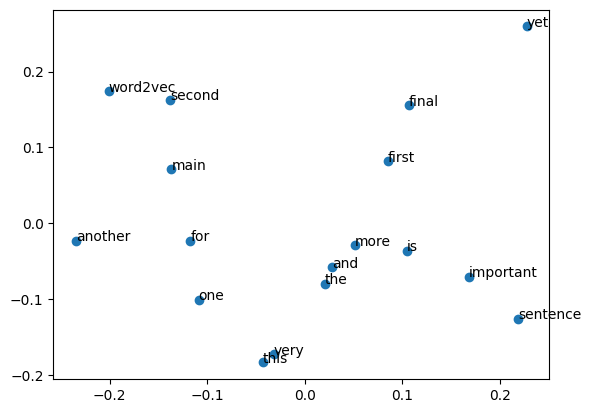

In [53]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
%matplotlib inline

words = list(model.wv.key_to_index.keys())
X = model.wv[words]
pca = PCA(n_components=2)
result = pca.fit_transform(X)

plt.scatter(result[:, 0], result[:, 1])

for i, word in enumerate(words):
    plt.annotate(word, xy=(result[i, 0], result[i, 1]))
plt.show()

# Using pre-trained Word2Vec model
- GoogleNews-vectors-negative300.bin
- Korean version "ko.vec" available

In [54]:
import gensim
from gensim.models import word2vec
from gensim.models import KeyedVectors
from sklearn.metrics.pairwise import cosine_similarity

- Its size is too big (bigger than 1.6 GB) and downloading may not be possible.

In [55]:
# skipped because of its huge size
'''
!wget -P ./ -c "https://s3.amazonaws.com/dl4j-distribution/GoogleNews-vectors-negative300.bin.gz"
EMBEDDING_FILE = './GoogleNews-vectors-negative300.bin.gz'
word_vectors = KeyedVectors.load_word2vec_format(EMBEDDING_FILE, binary=True)
print(word_vectors.vectors.shape)
'''

'\n!wget -P ./ -c "https://s3.amazonaws.com/dl4j-distribution/GoogleNews-vectors-negative300.bin.gz"\nEMBEDDING_FILE = \'./GoogleNews-vectors-negative300.bin.gz\'\nword_vectors = KeyedVectors.load_word2vec_format(EMBEDDING_FILE, binary=True)\nprint(word_vectors.vectors.shape)\n'

- Pre-trained Word2Vec
  - for english: (about 3 GB, and takes long to download): https://code.google.com/archive/p/word2vec
  - word vectors of 30+ languages: https://github.com/Kyubyong/wordvectors

# Glove - pretrained word embedder

In [56]:
import gensim.downloader as api

glove_model = api.load('glove-twitter-25')

[==================================================] 100.0% 104.8/104.8MB downloaded


In [57]:
glove_model['computer']

array([ 0.64005 , -0.019514,  0.70148 , -0.66123 ,  1.1723  , -0.58859 ,
        0.25917 , -0.81541 ,  1.1708  ,  1.1413  , -0.15405 , -0.11369 ,
       -3.8414  , -0.87233 ,  0.47489 ,  1.1541  ,  0.97678 ,  1.1107  ,
       -0.14572 , -0.52013 , -0.52234 , -0.92349 ,  0.34651 ,  0.061939,
       -0.57375 ], dtype=float32)

In [58]:
words = ["soccer", "football", "baseball", "volleyball", "basketball", "tennis",
         "persimmon", "softball", "apple", "hockey", "orange", "pear", "strawberry",
         "eat", "drink", "taste", "talk", "speak", "study", "research", "have", "take"]
mat = glove_model[words]
mat.shape

(22, 25)

In [59]:
v_apple = glove_model["apple"]
v_mango = glove_model["mango"]
print(v_apple.shape)
print(v_mango.shape)
cosine_similarity([v_mango],[v_apple])

(25,)
(25,)


array([[0.52559555]], dtype=float32)

In [60]:
glove_model.most_similar(["apple"]), glove_model.most_similar("tiger")

([('windows', 0.8948712944984436),
  ('microsoft', 0.8858076333999634),
  ('google', 0.8823867440223694),
  ('galaxy', 0.8806391358375549),
  ('flash', 0.8793812394142151),
  ('android', 0.8782057762145996),
  ('nokia', 0.8770236372947693),
  ('samsung', 0.8697316646575928),
  ('chrome', 0.8691699504852295),
  ('ipad', 0.8670315742492676)],
 [('eagle', 0.9295039772987366),
  ('blue', 0.8847297430038452),
  ('white', 0.8836454749107361),
  ('hawk', 0.8832809925079346),
  ('wing', 0.8700830936431885),
  ('golden', 0.8699467778205872),
  ('woods', 0.8693599104881287),
  ('wild', 0.8683100342750549),
  ('classic', 0.8648809194564819),
  ('yellow', 0.8638952970504761)])

- king - man + woman

In [61]:
glove_model.most_similar(positive=["king","woman"], negative=["man"])

[('meets', 0.8841923475265503),
 ('prince', 0.832163393497467),
 ('queen', 0.8257461190223694),
 ('’s', 0.8174097537994385),
 ('crow', 0.813499391078949),
 ('hunter', 0.8131037950515747),
 ('father', 0.8115833401679993),
 ('soldier', 0.81113600730896),
 ('mercy', 0.8082392811775208),
 ('hero', 0.8082262277603149)]

In [62]:
import matplotlib.pyplot as plt

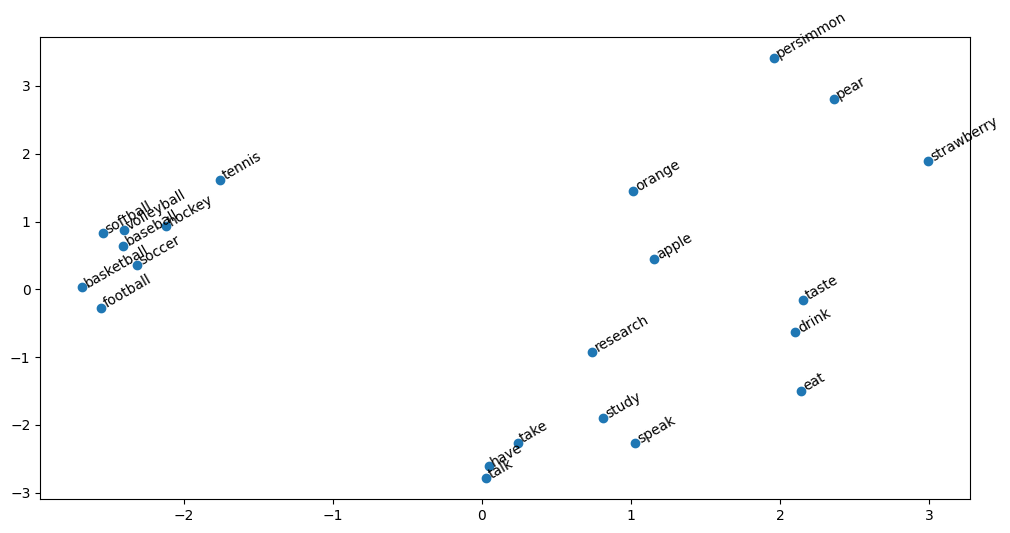

In [63]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
xys = pca.fit_transform(mat)
xs = xys[:,0]
ys = xys[:,1]

plt.figure(figsize=(12,6))
plt.scatter(xs, ys)

for i, word in enumerate(words):
    plt.annotate(word, xy=(xs[i], ys[i]), rotation=30)
plt.show()

# difference between Glove and Word2Vec

- Word2vec 임베딩은 얕은 피드포워드 신경망을 학습하는 데 기반을 두고 있는 반면, gloves 임베딩은 행렬 인수분해 기법을 기반으로 학습한다. gloves 모델은 전체 코퍼스를 활용하여 글로벌 단어 간 동시 발생 횟수를 활용하는 데 기반을 두고 있다. 반면 word2vec는 로컬 컨텍스트(인접 단어) 내에서 동시 발생을 활용한다.
- 두 모델은 대부분 비슷한 성능을 보이며, 모델 자체보다는 학습된 데이터 세트, 벡터의 길이 등과 같은 요인이 더 큰 영향을 미친다.

# Exercise (연습)

### KKma() 연습

In [64]:
# KoNLPy: 형태소 (뜻을 가진 최소 언어 단위) 분석
# kkma: Korean morpheme analyzer
# https://konlpy.org/ko/latest/morph/#pos-tagging-with-konlpy
from konlpy.tag import Kkma
kkma = Kkma()
print(kkma.sentences('네, 안녕하세요. 반갑습니다.'))
print(kkma.nouns('질문이나 건의사항은 깃헙 이슈 트래커에 남겨주세요.'))
print(kkma.pos('오류보고는 실행환경, 에러메세지와함께 설명을 최대한상세히!^^'))
# pos (part-of-speech): 품사 (명사, 동사, ...)

['네, 안녕하세요.', '반갑습니다.']
['질문', '건의', '건의사항', '사항', '깃헙', '이슈', '트래커']
[('오류', 'NNG'), ('보고', 'NNG'), ('는', 'JX'), ('실행', 'NNG'), ('환경', 'NNG'), (',', 'SP'), ('에러', 'NNG'), ('메세지', 'NNG'), ('와', 'JKM'), ('함께', 'MAG'), ('설명', 'NNG'), ('을', 'JKO'), ('최대한', 'NNG'), ('상세히', 'MAG'), ('!', 'SF'), ('^^', 'EMO')]
